In [41]:
train_path = "train.csv"
test_path  = "test.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

df_train.dropna(subset=['tweets', 'class'], inplace=True)
df_test.dropna(subset=['tweets'], inplace=True)

print(df_train.head())
print(df_train['class'].value_counts())


                                              tweets       class
0  Be aware  dirty step to get money  #staylight ...  figurative
1  #sarcasm for #people who don't understand #diy...  figurative
2  @IminworkJeremy @medsingle #DailyMail readers ...  figurative
3  @wilw Why do I get the feeling you like games?...  figurative
4  -@TeacherArthurG @rweingarten You probably jus...  figurative
class
figurative    21238
irony         20894
sarcasm       20681
regular       18595
Name: count, dtype: int64


KENAPA SAYA MENGHAPUS KELAS FIGURATIVE? 

Figurative bukan kategori linguistik yang jelas
Tidak punya marker leksikal kuat

Sangat overlap dengan irony dan sarcasm

Banyak paper menghindari kelas figurative atau menggabungkannya.

Berdasarkan evaluasi awal, kelas figurative menunjukkan performa yang sangat rendah dengan nilai precision, recall, dan F1-score sebesar 0.00. Hal ini disebabkan oleh sifat kelas figurative yang sangat ambigu dan tumpang tindih secara semantik dengan kelas irony dan sarcasm. Oleh karena itu, untuk meningkatkan stabilitas dan interpretabilitas model, penelitian ini mengecualikan kelas figurative dari proses pelatihan dan evaluasi lanjutan.

In [42]:
df_train[df_train['tweets'].str.contains('#sarcasm|#irony', case=False, na=False)].shape
df_train = df_train[df_train['class'] != 'figurative']
df_test  = df_test[df_test['class'] != 'figurative']

print("Kelas setelah filter:")
print(df_train['class'].value_counts())


Kelas setelah filter:
class
irony      20894
sarcasm    20681
regular    18595
Name: count, dtype: int64


eda

In [43]:
combined_data = pd.concat([df_train.assign(dataset='train'), df_test.assign(dataset='test')])

In [44]:
print("Jumlah data Train:", len(df_train))
print("Jumlah data Test:", len(df_test))
print("\nDistribusi kelas pada data training:")
print(combined_data['class'].value_counts())

Jumlah data Train: 60170
Jumlah data Test: 6082

Distribusi kelas pada data training:
class
irony      23005
sarcasm    22786
regular    20454
Name: count, dtype: int64


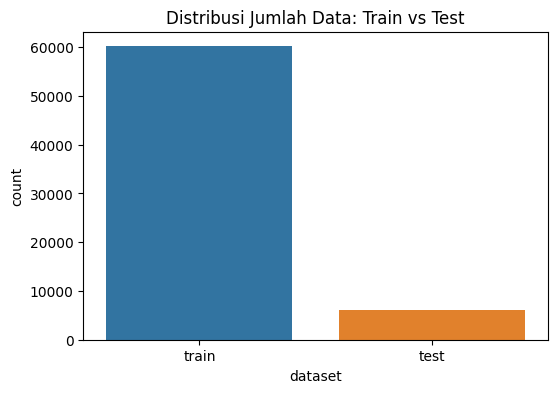

In [45]:
plt.figure(figsize=(6, 4))
sns.countplot(data=combined_data, x='dataset')
plt.title("Distribusi Jumlah Data: Train vs Test")
plt.show()

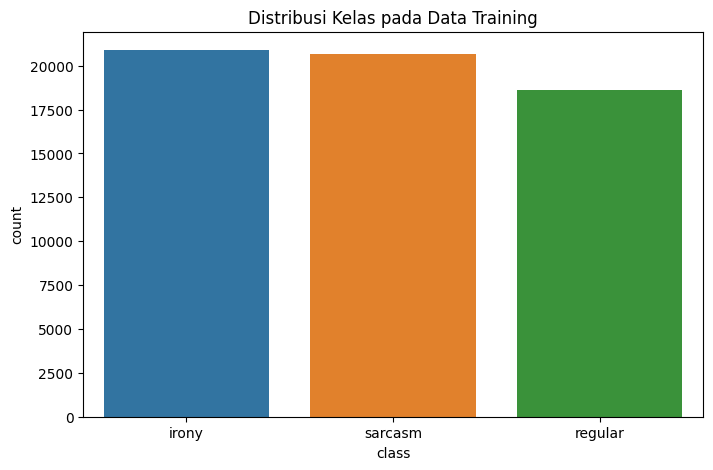

In [46]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='class', order=df_train['class'].value_counts().index)
plt.title("Distribusi Kelas pada Data Training")
plt.show()

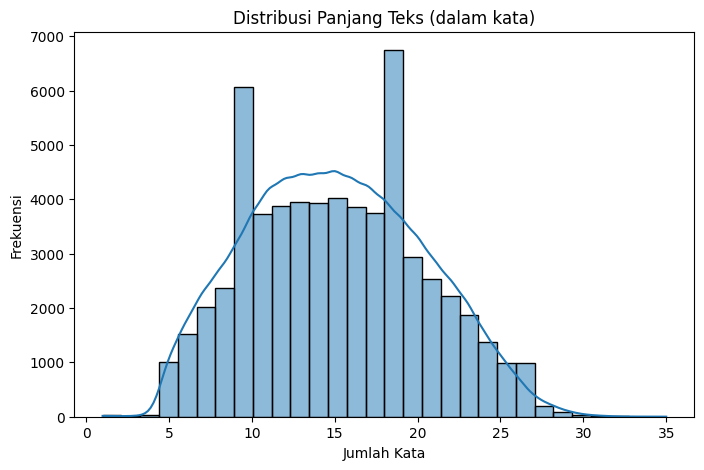

In [47]:
df_train['text_length'] = df_train['tweets'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 5))
sns.histplot(df_train['text_length'], bins=30, kde=True)
plt.title("Distribusi Panjang Teks (dalam kata)")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()